# 00 — Pipeline Overview & Configuration

Welcome to the **Pneumophonic Analysis Pipeline** notebook series. This pipeline jointly analyses
**Optoelectronic Plethysmography (OEP)** chest-wall kinematics and **acoustic voice** signals to
study respiratory–phonatory coupling (continuation of the Zocco 2025 thesis).

This notebook orients you: configuration, data layout, the OEP column model, the vocal-task protocol,
and the map from the original scripts to these notebooks. See **`NOTEBOOKS_GUIDE.md`** for the full
guide.

## Milestones
| Milestone | Notebook(s) | Question |
|-----------|-------------|----------|
| **M1** — paired extraction | `01` | build time-aligned `[audio \| OEP]` matrices |
| (visualization) | `02` | inspect one recording end-to-end |
| **M2** — correlation | `03`, `04` | does the voice covary with breathing? (+ effect sizes) |
| **M3** — modelling | `05`, `06` | can audio *predict* respiratory state? |
| acoustic / tasks | `07` | Praat metrics, segmentation, `Visualizer` |
| operatic singers | `08` | singer-specific features (vibrato, singer's formant, …) |
| diagnostics | `09` | cohort, coverage, HDF5 sanity checks |

## How to run
1. Use a Python env with the project deps (`pip install -r requirements.txt`) and the package
   installed (`pip install -e .`).
2. Open any notebook and **Run All**. Notebooks read the committed HDF5 corpus under
   `data_target/healthy_subjects/paired/`; audio-input notebooks (`07`, `08`) use synthetic signals
   because raw `.wav` files are not committed.
3. They are roughly ordered `00 → 09`; each is self-contained.

## 1. Package & configuration

In [1]:

import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd()
while not (REPO / "pneumophonic_analysis").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import pneumophonic_analysis as ppa
from pneumophonic_analysis import create_config
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

CFG = create_config()
print(f"pneumophonic_analysis v{ppa.__version__}")
params = pd.DataFrame([
    ("Audio sample rate", f"{CFG.audio.sample_rate} Hz"),
    ("STFT frame length", f"{CFG.audio.frame_length_samples} samples ({CFG.audio.frame_length_ms:.0f} ms)"),
    ("STFT hop length", f"{CFG.audio.hop_length_samples} samples"),
    ("Audio feature rate", f"{CFG.audio.sample_rate/CFG.audio.hop_length_samples:.1f} fps"),
    ("Mel bands / MFCCs", f"{CFG.audio.n_mels} / {CFG.audio.n_mfcc}"),
    ("OEP kinematic rate", f"{CFG.oep.fs_kinematic} Hz"),
    ("F0 range (pitch cfg)", f"{CFG.pitch.f0_min}–{CFG.pitch.f0_max} Hz"),
], columns=["parameter", "value"])
display(params)

pneumophonic_analysis v1.0.0


,parameter,value
0,Audio sample rate,48000 Hz
1,STFT frame length,1440 samples (30 ms)
2,STFT hop length,720 samples
3,Audio feature rate,66.7 fps
4,Mel bands / MFCCs,64 / 13
5,OEP kinematic rate,50 Hz
6,F0 range (pitch cfg),50–500 Hz


## 2. Data layout
```
pneumophonic_pipeline/
├── data_root/<batch>/                 # source (read-only, not committed)
│   ├── subjects_metadata.csv          # ID; DoB; acquisition; Age; Gender
│   └── YYYYMMDD_<SubjectID>/
│       ├── renders/*.wav              # audio per task
│       ├── csv/<ID>_<task>.csv        # OEP volumes + sync
│       ├── sync_signal.wav            # sync pulse
│       └── <ID>_audio.xlsx            # Timing sheet (start, stop, falling edge)
├── data_target/<batch>/
│   ├── paired/*.h5                    # M1 output (committed corpus used here)
│   ├── m2_correlation/                # M2 PDFs/CSVs
│   ├── M2_stratified/ M3_*/           # L3 / M3 outputs
│   └── figures/paired/<ID>/           # per-subject PDFs
├── pneumophonic_analysis/             # core package (11 modules)
├── scripts/                           # standalone analysis scripts
└── notebooks/                         # << you are here >>
```
`<batch>` is `healthy_subjects` or `pathological_subjects`.

## 3. OEP two-compartment model
| Col | Label | Quantity | Model |
|-----|-------|----------|-------|
| `A` | Vrcp | pulmonary rib cage | **Vrc = A + B** |
| `B` | Vrca | abdominal rib cage | |
| `C` | Vab  | abdomen | **Vab = C** |
| `tot_vol` | Vcw | total chest wall | **A + B + C = Vcw** |

## 4. Vocal tasks (Zocco protocol)
| Label | Audio | OEP CSV | Description |
|-------|-------|---------|-------------|
| `a` `e` `i` `o` `u` | `{v}.wav` | `Vocali` | sustained vowels (5 s) |
| `a_2` | `phonema_a_2.wav` | `phonema_a_2` | maximum phonation time /a/ |
| `a_3` | `phonema_a_3.wav` | `phonema_a_3` | soft phonation /a/ |
| `a_7` | `phonema_a_7.wav` | `phonema_a_7` | vocal glide |
| `r` | `r.wav` | `r` | sustained alveolar trill |
| `f_1..f_5` | `phrase_{n}.wav` | `frasi` | sentence reading |
| `testo` | `testo.wav` | `testo` | balanced text reading |

## 5. Script → notebook map
Where each original script now lives.

In [2]:

mapping = pd.DataFrame([
    ("test_paired.py / batch_extract.py", "paired_features.py", "01"),
    ("plot_paired_features.py / batch_plot_paired.py", "visualization.py", "02"),
    ("m2_correlation.py", "—", "03"),
    ("analyze_l3_stratified.py / make_m2_summary_plots.py", "effect_size.py", "04"),
    ("analyze_compartmental_regression.py / diagnose_compartmental_signal.py", "—", "05"),
    ("analyze_frc_classification.py / analyze_frc_window_sweep.py", "—", "06"),
    ("analyze_single_subject.py / analyze_trill_modulation.py", "acoustic_features, segmentation, task_analyzers, visualization", "07"),
    ("(operatic_acoustic_analysis.ipynb)", "singer_acoustc_features.py", "08"),
    ("tools.py / count_check.py / tool_h5_id_match.py", "—", "09"),
], columns=["script(s)", "core module(s)", "notebook"])
display(mapping)

,script(s),core module(s),notebook
0,test_paired.py / batch_extract.py,paired_features.py,01
1,plot_paired_features.py / batch_plot_paired.py,visualization.py,02
2,m2_correlation.py,—,03
3,analyze_l3_stratified.py / make_m2_summary_plo...,effect_size.py,04
4,analyze_compartmental_regression.py / diagnose...,—,05
5,analyze_frc_classification.py / analyze_frc_wi...,—,06
6,analyze_single_subject.py / analyze_trill_modu...,"acoustic_features, segmentation, task_analyzer...",07
7,(operatic_acoustic_analysis.ipynb),singer_acoustc_features.py,08
8,tools.py / count_check.py / tool_h5_id_match.py,—,09


## 6. A teaser — one recording, two systems on one axis
The whole point of M1: audio energy and chest-wall volume on a shared time axis.

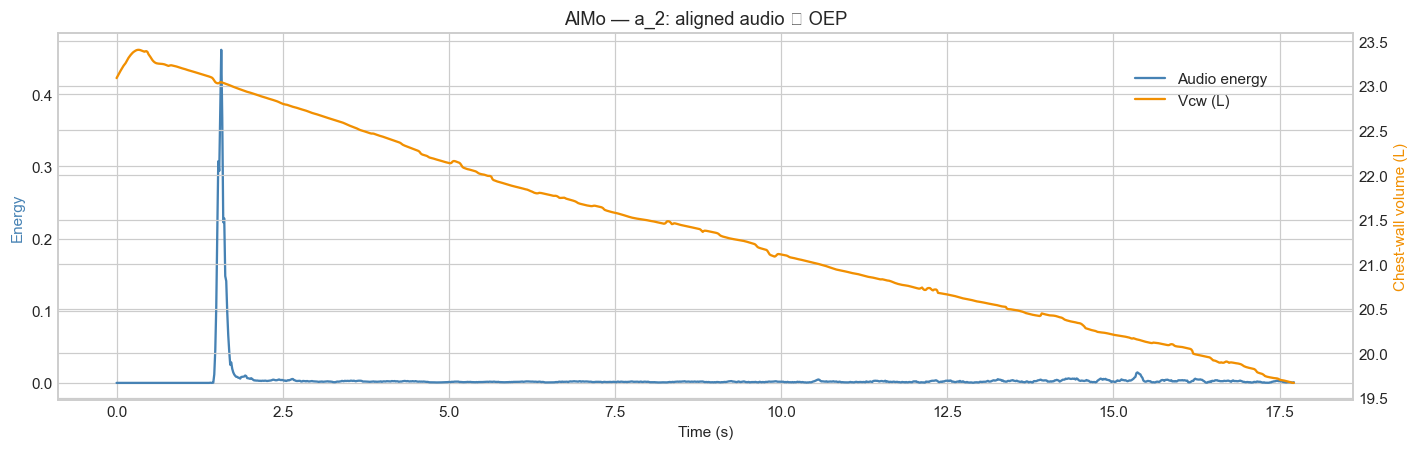

Corpus: 546 recordings under data_target\healthy_subjects\paired


In [3]:

from pneumophonic_analysis.paired_features import PairedFeatureExtractor
PAIRED_DIR = REPO / "data_target" / "healthy_subjects" / "paired"
h5_files = sorted(PAIRED_DIR.glob("*.h5"))
if h5_files:
    H5 = next((f for f in h5_files if f.stem.endswith('_a_2')), h5_files[0])
    df, meta = PairedFeatureExtractor.load_hdf5(H5)
    fig, ax1 = plt.subplots(figsize=(13, 4.2))
    ax1.plot(df['time'], df['energy'], color='steelblue', label='Audio energy')
    ax1.set_ylabel('Energy', color='steelblue'); ax1.set_xlabel('Time (s)')
    ax2 = ax1.twinx(); ax2.plot(df['time'], df['vcw'], color='#F18F01', label='Vcw (L)')
    ax2.set_ylabel('Chest-wall volume (L)', color='#F18F01')
    ax1.set_title(f"{meta['subject_id']} — {meta['task_name']}: aligned audio ⊕ OEP")
    fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.86)); plt.tight_layout(); plt.show()
    print(f"Corpus: {len(h5_files)} recordings under {PAIRED_DIR.relative_to(REPO)}")
else:
    print("No HDF5 corpus found — run scripts/batch_extract.py.")

In [4]:
# ---- Optional: overlay the raw source waveform + audio player ----
# Runs only if the raw .wav is available locally; the committed corpus is HDF5-only,
# so this panel is skipped on a clean checkout (raw audio lives outside the repo).
import librosa
from IPython.display import Audio

PAIRED_DIR = REPO / "data_target" / "healthy_subjects" / "paired"
H5 = next(f for f in sorted(PAIRED_DIR.glob("*_a_2.h5")))
df, meta = PairedFeatureExtractor.load_hdf5(H5)
SUBJ = meta['subject_id']; TASK = meta['task_name']

wav_candidates = list(
    (REPO / "data_root" / "healthy_subjects").glob(f"**/{SUBJ}*/renders/phonema_{TASK}.wav")
)
if not wav_candidates:
    print(f"Raw source WAV for {SUBJ}/{TASK} not available locally "
          f"(the committed corpus is HDF5-only) — skipping the waveform + audio-player panel.")
else:
    WAV = wav_candidates[0]
    y, sr = librosa.load(str(WAV), sr=None, mono=True)
    t_wav = np.arange(len(y)) / sr
    fig, axes = plt.subplots(3, 1, figsize=(13, 8.5))
    axes[0].plot(t_wav, y, color='steelblue', linewidth=0.4)
    axes[0].set_title(f"{SUBJ} — {TASK}: source waveform  ({WAV.name},  dur = {len(y)/sr:.2f} s)")
    axes[0].set_ylabel('Amplitude'); axes[0].set_xlabel('Time (s, source-relative)')
    axes[0].axhline(0, color='k', linewidth=0.3)
    ax1 = axes[1]
    ax1.plot(df['time'], df['energy'], color='steelblue', label='energy')
    ax1.set_ylabel('Audio energy', color='steelblue'); ax1.set_xlabel('Time (s, paired)')
    ax2 = ax1.twinx(); ax2.plot(df['time'], df['vcw'], color='#F18F01', label='Vcw')
    ax2.set_ylabel('Vcw (L)', color='#F18F01')
    ax1.set_title(f"Paired energy ⊕ Vcw  (paired dur = {meta['audio_duration_sec']:.2f} s)")
    hop = int(meta['hop_length'])
    y_rms = librosa.feature.rms(y=y, frame_length=hop*2, hop_length=hop, center=True)[0]
    t_rms = np.arange(len(y_rms)) * hop / sr
    axes[2].plot(t_rms, y_rms, color='darkgreen')
    axes[2].set_title('Independent RMS from source waveform (librosa.feature.rms)')
    axes[2].set_ylabel('RMS'); axes[2].set_xlabel('Time (s, source-relative)')
    plt.tight_layout(); plt.show()
    print(f"Source WAV: {len(y)/sr:.2f}s   |   Paired segment: {meta['audio_duration_sec']:.2f}s   |   sr={sr}")
    display(Audio(data=y, rate=sr))

Raw source WAV for AlMo/a_2 not available locally (the committed corpus is HDF5-only) — skipping the waveform + audio-player panel.


## Next
Continue with **`01_M1_paired_feature_extraction.ipynb`**, or jump to whichever milestone you need.
Full documentation: **`NOTEBOOKS_GUIDE.md`**.